# COO Delivery Performance Analysis

**Business context:** Campaign dashboards, churn metrics and complaints suggest weak customer engagement, but the likely root cause may be operational delivery performance rather than brand stickiness.

This notebook analyses `fact_orders.csv` exported from BigQuery and tests whether delivery failures are associated with worse review scores, complaint proxies and repeat-purchase behaviour.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "fact_orders.csv"  # update path if needed

df = pd.read_csv(CSV_PATH)

for c in ["purchase_ts", "approved_ts", "delivered_ts", "estimated_ts"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")

df.head()

,order_id,customer_id,order_status,purchase_ts,approved_ts,delivered_ts,estimated_ts,payment_value,order_gmv,order_freight,item_count,customer_unique_id,customer_state,review_score
0,2e7a8482f6fb09756ca50c10d7bfc047,08c5351a6aca1c1589a38f244edeee9d,shipped,2016-09-04 21:15:19+00:00,2016-10-07 13:18:03+00:00,NaT,2016-10-20 00:00:00+00:00,136.23,72.89,63.34,2,b7d76e111c89f7ebf14761390f0f7d17,RR,1.0
1,616766a13421c758b45c1912e9e4fedf,0a4e3807c23f486dea9adbdf8c73a70a,delivered,2017-03-08 23:21:32+00:00,2017-03-08 23:21:32+00:00,2017-03-28 16:14:54+00:00,2017-04-06 00:00:00+00:00,134.96,109.99,24.97,1,fc4249eb9b18bed24ff89e4a34eafa69,SE,1.0
2,285ab9426d6982034523a855f55a885e,9cf2c3fa2632cee748e1a59ca9d09b21,delivered,2017-03-08 22:47:40+00:00,2017-03-08 22:47:40+00:00,2017-09-19 14:00:04+00:00,2017-04-06 00:00:00+00:00,457.65,429.90,27.75,1,3c2564d42f7ddd8b7576f0dd9cb1b4c5,SE,1.0
3,f0df036e9be21fc238f131bbfcdde769,1fa16395beca89233661543954ca6cf1,unavailable,2017-02-24 23:39:21+00:00,2017-02-24 23:45:14+00:00,NaT,2017-04-07 00:00:00+00:00,59.74,NaN,NaN,1,61181b9bc9188678b5991d89064dd961,RO,1.0
4,657467884d9a109179d820f67575db18,7c548882bf83f9fbe5cb6131a81e0839,canceled,2017-02-16 11:29:08+00:00,2017-02-18 11:25:14+00:00,NaT,2017-04-18 00:00:00+00:00,140.00,90.00,50.00,1,6993190a7c6a252ad0afb5128c8522a4,PI,1.0


In [4]:
# Derived delivery and customer experience fields

df["purchase_month"] = df["purchase_ts"].dt.to_period("M").astype(str)
df["delivery_days"] = (df["delivered_ts"] - df["purchase_ts"]).dt.total_seconds() / 86400
df["delay_days"] = (df["delivered_ts"] - df["estimated_ts"]).dt.total_seconds() / 86400

df["is_delivered"] = df["delivered_ts"].notna()
df["is_late"] = df["delay_days"] > 0

# Review score as NPS proxy:
# 5 = promoter, 4 = passive, <=3 = detractor
df["is_promoter"] = df["review_score"].eq(5)
df["is_detractor"] = df["review_score"].le(3)
df["is_low_review"] = df["review_score"].le(2)

def delivery_bucket(row):
    if pd.isna(row["delivered_ts"]):
        return "Not delivered"
    if pd.isna(row["delay_days"]):
        return "Unknown"
    if row["delay_days"] <= 0:
        return "On time / early"
    if row["delay_days"] <= 3:
        return "1-3 days late"
    if row["delay_days"] <= 7:
        return "4-7 days late"
    return "8+ days late"

df["delivery_bucket"] = df.apply(delivery_bucket, axis=1)

bucket_order = ["On time / early", "1-3 days late", "4-7 days late", "8+ days late", "Not delivered"]

df[["order_id", "delivery_bucket", "delivery_days", "delay_days", "review_score"]].head()

/tmp/ipykernel_172471/2832277697.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["purchase_month"] = df["purchase_ts"].dt.to_period("M").astype(str)


,order_id,delivery_bucket,delivery_days,delay_days,review_score
0,2e7a8482f6fb09756ca50c10d7bfc047,Not delivered,NaN,NaN,1.0
1,616766a13421c758b45c1912e9e4fedf,On time / early,19.703727,-8.322986,1.0
2,285ab9426d6982034523a855f55a885e,8+ days late,194.633611,166.583380,1.0
3,f0df036e9be21fc238f131bbfcdde769,Not delivered,NaN,NaN,1.0
4,657467884d9a109179d820f67575db18,Not delivered,NaN,NaN,1.0


## 1. Delivery performance summary

This table checks whether delivery failure is associated with lower review scores and a worse NPS proxy.

`nps_proxy = promoter_rate - detractor_rate`, where:
- promoter = review score 5
- detractor = review score 1 to 3


In [5]:
delivery_summary = (
    df.groupby("delivery_bucket")
      .agg(
          orders=("order_id", "nunique"),
          avg_review=("review_score", "mean"),
          low_review_rate=("is_low_review", "mean"),
          detractor_rate=("is_detractor", "mean"),
          promoter_rate=("is_promoter", "mean"),
          avg_delivery_days=("delivery_days", "mean"),
          avg_delay_days=("delay_days", "mean"),
          total_gmv=("order_gmv", "sum"),
      )
      .reindex(bucket_order)
)

delivery_summary["order_share"] = delivery_summary["orders"] / df["order_id"].nunique()
delivery_summary["nps_proxy"] = delivery_summary["promoter_rate"] - delivery_summary["detractor_rate"]

delivery_summary.style.format({
    "avg_review": "{:.2f}",
    "low_review_rate": "{:.1%}",
    "detractor_rate": "{:.1%}",
    "promoter_rate": "{:.1%}",
    "order_share": "{:.1%}",
    "nps_proxy": "{:.1%}",
    "avg_delivery_days": "{:.1f}",
    "avg_delay_days": "{:.1f}",
    "total_gmv": "{:,.0f}",
})

,orders,avg_review,low_review_rate,detractor_rate,promoter_rate,avg_delivery_days,avg_delay_days,total_gmv,order_share,nps_proxy
delivery_bucket,,,,,,,,,,
On time / early,88649,4.30,9.1%,16.9%,61.8%,10.9,-13.0,"12,061,945",89.1%,44.9%
1-3 days late,2662,3.77,18.7%,32.9%,42.6%,21.1,1.4,"359,362",2.7%,9.7%
4-7 days late,1819,2.32,59.5%,70.0%,17.6%,26.7,5.1,"280,401",1.8%,-52.4%
8+ days late,3346,1.73,75.7%,84.5%,7.2%,42.5,18.4,"519,188",3.4%,-77.2%
Not delivered,2965,1.75,73.7%,80.8%,8.6%,nan,nan,"370,749",3.0%,-72.3%


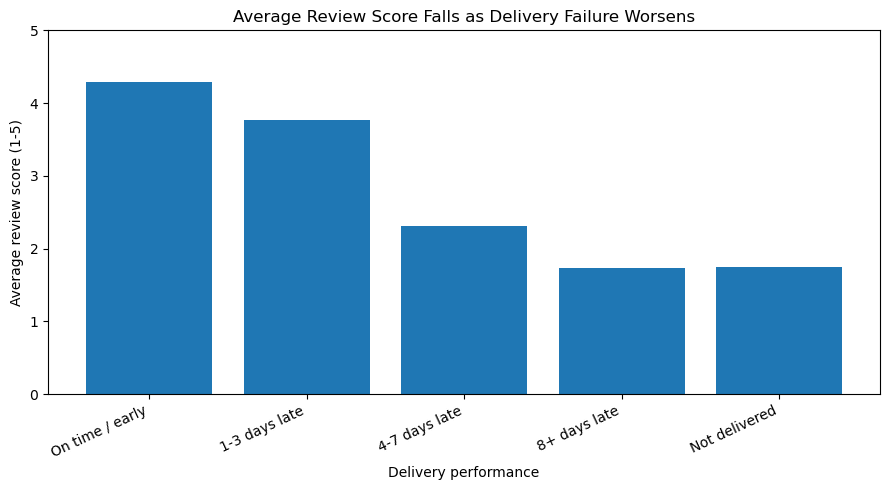

In [6]:
plt.figure(figsize=(9, 5))
plt.bar(delivery_summary.index, delivery_summary["avg_review"])
plt.title("Average Review Score Falls as Delivery Failure Worsens")
plt.xlabel("Delivery performance")
plt.ylabel("Average review score (1-5)")
plt.ylim(0, 5)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

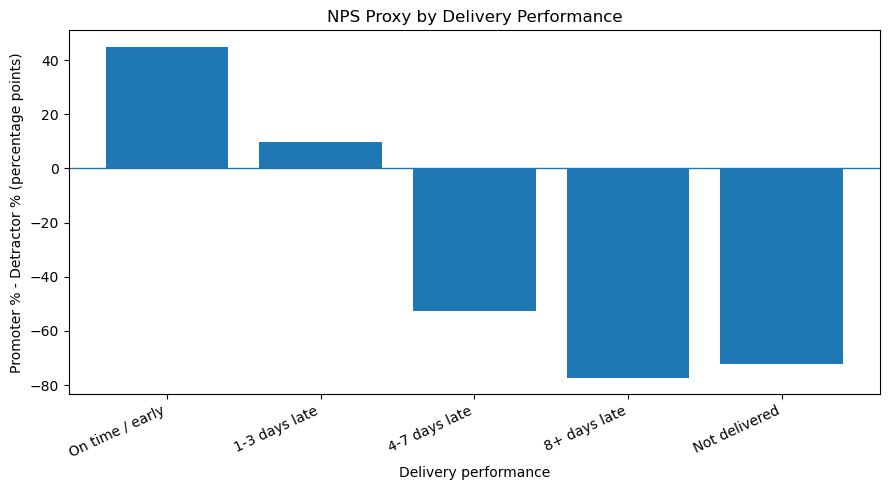

In [7]:
plt.figure(figsize=(9, 5))
plt.bar(delivery_summary.index, delivery_summary["nps_proxy"] * 100)
plt.title("NPS Proxy by Delivery Performance")
plt.xlabel("Delivery performance")
plt.ylabel("Promoter % - Detractor % (percentage points)")
plt.axhline(0, linewidth=1)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

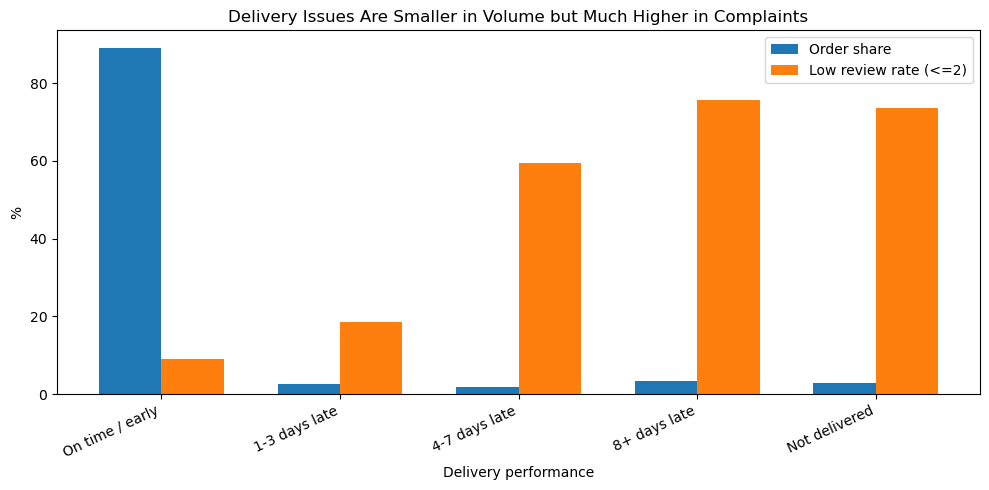

In [8]:
x = np.arange(len(delivery_summary.index))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, delivery_summary["order_share"] * 100, width, label="Order share")
plt.bar(x + width/2, delivery_summary["low_review_rate"] * 100, width, label="Low review rate (<=2)")
plt.title("Delivery Issues Are Smaller in Volume but Much Higher in Complaints")
plt.xlabel("Delivery performance")
plt.ylabel("%")
plt.xticks(x, delivery_summary.index, rotation=25, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## 2. Monthly pattern

This checks whether operational issues move together with complaint proxies over time.


In [9]:
monthly = (
    df.groupby("purchase_month")
      .agg(
          orders=("order_id", "nunique"),
          late_rate=("is_late", "mean"),
          not_delivered_rate=("is_delivered", lambda s: 1 - s.mean()),
          avg_review=("review_score", "mean"),
          low_review_rate=("is_low_review", "mean"),
      )
      .reset_index()
)

# Keep only months with enough order volume to avoid partial-month noise
monthly = monthly[monthly["orders"] >= 100]

monthly.tail()

,purchase_month,orders,late_rate,not_delivered_rate,avg_review,low_review_rate
18,2018-04,6939,0.052025,0.020320,4.162909,0.128405
19,2018-05,6873,0.080896,0.018042,4.194176,0.118580
20,2018-06,6167,0.013459,0.011513,4.277207,0.107183
21,2018-07,6292,0.043865,0.021615,4.265434,0.109027
22,2018-08,6512,0.101351,0.024724,4.265139,0.106112


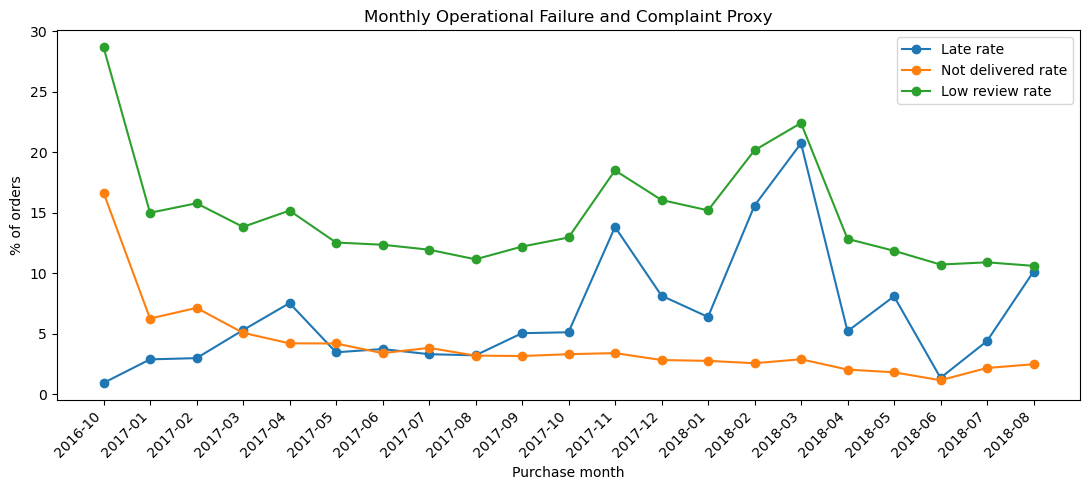

In [10]:
plt.figure(figsize=(11, 5))
plt.plot(monthly["purchase_month"], monthly["late_rate"] * 100, marker="o", label="Late rate")
plt.plot(monthly["purchase_month"], monthly["not_delivered_rate"] * 100, marker="o", label="Not delivered rate")
plt.plot(monthly["purchase_month"], monthly["low_review_rate"] * 100, marker="o", label="Low review rate")
plt.title("Monthly Operational Failure and Complaint Proxy")
plt.xlabel("Purchase month")
plt.ylabel("% of orders")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Repeat-purchase / churn proxy

The fact table does not contain email campaign exposure or true churn labels. As a proxy, we check whether a customer placed more than one order.

For Olist-style datasets, repeat rates are usually low, so treat this as directional only.


In [11]:
customer_first = (
    df.sort_values(["customer_unique_id", "purchase_ts"])
      .groupby("customer_unique_id")
      .agg(
          order_count=("order_id", "nunique"),
          first_delivery_bucket=("delivery_bucket", "first"),
          first_review_score=("review_score", "first"),
      )
      .reset_index()
)

customer_first["has_repeat"] = customer_first["order_count"] > 1

repeat_summary = (
    customer_first.groupby("first_delivery_bucket")
      .agg(
          customers=("customer_unique_id", "nunique"),
          repeat_customers=("has_repeat", "sum"),
          repeat_rate=("has_repeat", "mean"),
          avg_first_review=("first_review_score", "mean"),
      )
      .reindex(bucket_order)
)

repeat_summary.style.format({
    "repeat_rate": "{:.2%}",
    "avg_first_review": "{:.2f}",
})

,customers,repeat_customers,repeat_rate,avg_first_review
first_delivery_bucket,,,,
On time / early,85660,2681,3.13%,4.29
1-3 days late,2575,63,2.45%,3.77
4-7 days late,1769,43,2.43%,2.31
8+ days late,3248,88,2.71%,1.73
Not delivered,2844,122,4.29%,1.75


## 4. State-level operational priority

This helps the COO decide where to investigate first.

Priority score is a simple operational ranking:

`orders × (late_rate + not_delivered_rate) × (5 - avg_review)`


In [12]:
state_summary = (
    df.groupby("customer_state")
      .agg(
          orders=("order_id", "nunique"),
          late_rate=("is_late", "mean"),
          not_delivered_rate=("is_delivered", lambda s: 1 - s.mean()),
          avg_review=("review_score", "mean"),
          low_review_rate=("is_low_review", "mean"),
          promoter_rate=("is_promoter", "mean"),
          detractor_rate=("is_detractor", "mean"),
          total_gmv=("order_gmv", "sum"),
      )
      .reset_index()
)

state_summary["bad_delivery_rate"] = state_summary["late_rate"] + state_summary["not_delivered_rate"]
state_summary["nps_proxy"] = state_summary["promoter_rate"] - state_summary["detractor_rate"]
state_summary["priority_score"] = (
    state_summary["orders"] *
    state_summary["bad_delivery_rate"] *
    (5 - state_summary["avg_review"])
)

top_states = state_summary.sort_values("priority_score", ascending=False).head(10)

top_states.style.format({
    "late_rate": "{:.1%}",
    "not_delivered_rate": "{:.1%}",
    "bad_delivery_rate": "{:.1%}",
    "avg_review": "{:.2f}",
    "low_review_rate": "{:.1%}",
    "nps_proxy": "{:.1%}",
    "total_gmv": "{:,.0f}",
    "priority_score": "{:,.0f}",
})

,customer_state,orders,late_rate,not_delivered_rate,avg_review,low_review_rate,promoter_rate,detractor_rate,total_gmv,bad_delivery_rate,nps_proxy,priority_score
26,SP,41746,5.7%,3.0%,4.18,12.4%,0.596153,0.202055,"5,202,955",8.7%,39.4%,"2,996"
18,RJ,12852,12.9%,3.9%,3.88,20.1%,0.534781,0.281902,"1,824,093",16.8%,25.3%,"2,416"
10,MG,11634,5.5%,2.4%,4.14,13.0%,0.582603,0.212309,"1,585,287",7.9%,37.0%,790
4,BA,3380,13.5%,3.7%,3.86,18.6%,0.482544,0.283728,"511,350",17.2%,19.9%,661
22,RS,5466,7.0%,2.2%,4.14,13.1%,0.580132,0.212038,"750,304",9.2%,36.8%,434
23,SC,3637,9.5%,2.5%,4.08,14.3%,0.562277,0.230685,"520,553",12.0%,33.2%,402
17,PR,5045,4.9%,2.4%,4.18,12.2%,0.594648,0.197225,"683,084",7.3%,39.7%,300
5,CE,1336,14.7%,4.3%,3.86,19.4%,0.502246,0.291916,"227,255",18.9%,21.0%,288
7,ES,2033,12.0%,1.9%,4.04,14.7%,0.539105,0.236104,"275,037",13.9%,30.3%,271
15,PE,1652,10.4%,3.6%,4.01,16.6%,0.551453,0.244552,"262,788",14.0%,30.7%,229


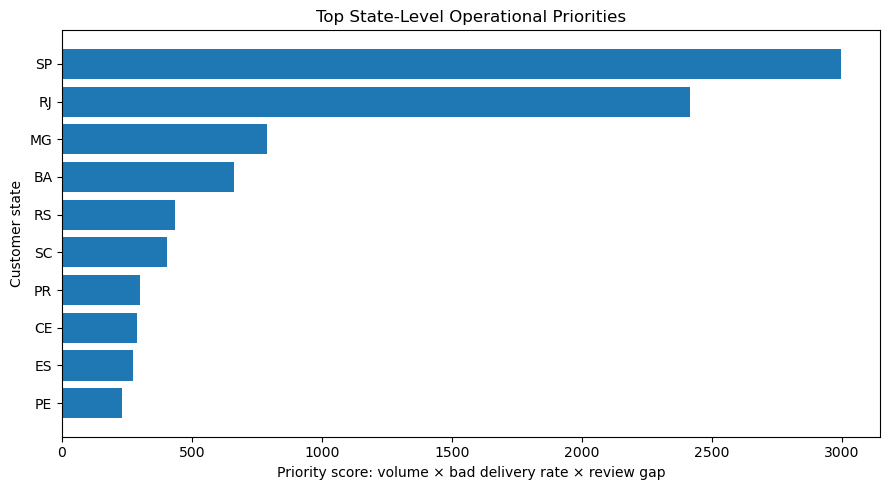

In [13]:
plot_df = top_states.sort_values("priority_score")

plt.figure(figsize=(9, 5))
plt.barh(plot_df["customer_state"], plot_df["priority_score"])
plt.title("Top State-Level Operational Priorities")
plt.xlabel("Priority score: volume × bad delivery rate × review gap")
plt.ylabel("Customer state")
plt.tight_layout()
plt.show()

## Executive interpretation

The analysis is designed to support or challenge the COO's initial assumption.

If late and undelivered orders have materially lower reviews, higher detractor rates and worse NPS proxy, the business problem should be framed as an operational delivery reliability issue first, not a marketing or brand-stickiness issue.

Recommended next step:
1. Prioritise states with high operational priority scores.
2. Investigate carriers/sellers/routes behind late and undelivered orders.
3. Measure whether fixing delivery reliability improves review score, complaint rate and repeat behaviour before increasing loyalty-programme spend.
